# OSINT Entity Resolution - Data Exploration

This notebook explores the entity resolution dataset to understand:
- Data structure and schema
- Class balance (positive vs negative matches)
- Entity attributes and completeness
- Data quality issues

In [1]:
import json
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Add scripts to path
sys.path.append('..')
from scripts.load_data import load_pairs, create_sample, load_sample, load_full_dataset

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Create Sample Data

First, let's create a small sample to explore quickly.

In [11]:
# ============================================
# CONFIGURATION: Toggle between sample and full dataset
# ============================================
USE_SAMPLE = False  # Set to False to use full dataset (755k entries, ~10 GB)

if USE_SAMPLE:
    # Option A: Use sample data (1,000 entries)
    print("📊 Using SAMPLE mode: 1,000 entries")
    sample_path = Path('../data/samples/sample_1000.json')
    
    # Create sample if it doesn't exist
    if not sample_path.exists():
        print("Creating sample...")
        create_sample('../data/raw/pairs-20251209.json.gz', str(sample_path), n=1000)
    
    # Load sample
    data = load_sample(sample_path)
    print(f"✓ Loaded {len(data):,} samples")
    
else:
    # Option B: Use full dataset (755,540 entries)
    print("📊 Using FULL DATASET mode: ~755,540 entries")
    print("⚠️  Memory usage: ~10 GB")
    
    # Load full dataset with caching
    data = load_full_dataset(
        input_path='../data/raw/pairs-20251209.json.gz',
        cache_path='../data/raw/pairs_full.json',
        use_cache=True
    )
    print(f"✓ Loaded {len(data):,} pairs")

📊 Using FULL DATASET mode: ~755,540 entries
⚠️  Memory usage: ~10 GB
Loading from cache: ../data/raw/pairs_full.json
✓ Loaded 755,540 pairs from cache in 48.71s
✓ Loaded 755,540 pairs


## 2. Inspect Data Structure

Let's look at a few examples to understand the schema.

In [12]:
# Display first example (positive match)
print("=" * 80)
print("EXAMPLE 1: Full structure")
print("=" * 80)
print(json.dumps(data[0], indent=2))

EXAMPLE 1: Full structure
{
  "left": {
    "id": "eu-fsf-eu-3298-47",
    "caption": "\u0645\u062b\u0646\u0649 \u062d\u0627\u0631\u062b \u0633\u0644\u0645\u0627\u0646 \u0627\u0644\u0636\u0627\u0631\u064a",
    "schema": "Person",
    "referents": [],
    "datasets": [
      "eu_fsf",
      "be_fod_sanctions"
    ],
    "first_seen": "2023-04-20T12:13:17",
    "last_seen": "2025-11-13T09:17:02",
    "last_change": "2025-05-16T12:17:03",
    "properties": {
      "birthDate": [
        "1969",
        "1969-06-16"
      ],
      "middleName": [
        "Harith",
        "Haris",
        "Harith Sulayman",
        "Hareth"
      ],
      "name": [
        "Doctor Muthanna Harith Sulayman Al Dari Al-Zawba\u2019",
        "Muthanna Hareth al-Dari",
        "Muthanna Harith Sulayman Al-Dari Al-Zobai",
        "Muthanna Harith Al-Dari",
        "Muthanna Al Dari",
        "Dr. Muthanna Harith al-Dari al-Zowbai",
        "Muthana Haris al-Dari",
        "Muthanna Hareth Al-Dhari",
        "Mu

In [13]:
# Inspect the keys in entity data
print("Keys in 'left' entity:")
print(list(data[0]['left'].keys()))
print("\nKeys in 'right' entity:")
print(list(data[0]['right'].keys()))

Keys in 'left' entity:
['id', 'caption', 'schema', 'referents', 'datasets', 'first_seen', 'last_seen', 'last_change', 'properties', 'target']

Keys in 'right' entity:
['id', 'caption', 'schema', 'referents', 'datasets', 'first_seen', 'last_seen', 'last_change', 'properties', 'target']


## 3. Class Balance

Examine the distribution of positive vs negative matches.

Class Distribution:
  positive: 581149 (76.9%)
  negative: 174391 (23.1%)


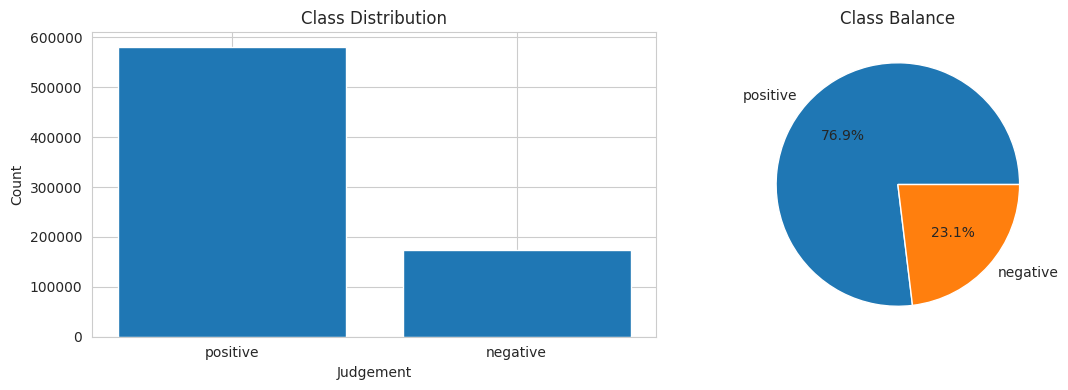

In [14]:
# Count judgements
judgements = [pair['judgement'] for pair in data]
judgement_counts = Counter(judgements)

print("Class Distribution:")
for label, count in judgement_counts.items():
    pct = (count / len(data)) * 100
    print(f"  {label}: {count} ({pct:.1f}%)")

# Visualize
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
ax[0].bar(judgement_counts.keys(), judgement_counts.values())
ax[0].set_xlabel('Judgement')
ax[0].set_ylabel('Count')
ax[0].set_title('Class Distribution')

# Pie chart
ax[1].pie(judgement_counts.values(), labels=judgement_counts.keys(), autopct='%1.1f%%')
ax[1].set_title('Class Balance')

plt.tight_layout()
plt.show()

## 4. Entity Attribute Analysis

Analyze which attributes are present and how complete they are.

In [15]:
# Collect all unique keys from left and right entities
all_left_keys = set()
all_right_keys = set()

for pair in data:
    all_left_keys.update(pair['left'].keys())
    all_right_keys.update(pair['right'].keys())

print(f"Unique attributes in 'left' entities: {len(all_left_keys)}")
print(f"Unique attributes in 'right' entities: {len(all_right_keys)}")
print(f"\nCommon attributes: {all_left_keys & all_right_keys}")
print(f"Only in left: {all_left_keys - all_right_keys}")
print(f"Only in right: {all_right_keys - all_left_keys}")

Unique attributes in 'left' entities: 11
Unique attributes in 'right' entities: 11

Common attributes: {'datasets', 'properties', 'last_change', 'target', 'caption', 'first_seen', 'origin', 'schema', 'last_seen', 'referents', 'id'}
Only in left: set()
Only in right: set()


In [16]:
# Calculate attribute completeness (non-null, non-empty values)
def calculate_completeness(entities, attribute):
    """Calculate % of entities that have a non-empty value for attribute."""
    count = sum(
        1 for entity in entities 
        if attribute in entity and entity[attribute] and str(entity[attribute]).strip()
    )
    return (count / len(entities)) * 100 if entities else 0

# Get all entities
left_entities = [pair['left'] for pair in data]
right_entities = [pair['right'] for pair in data]

# Calculate completeness for common attributes
common_attrs = sorted(all_left_keys & all_right_keys)
completeness_data = []

for attr in common_attrs:
    left_comp = calculate_completeness(left_entities, attr)
    right_comp = calculate_completeness(right_entities, attr)
    completeness_data.append({
        'attribute': attr,
        'left_completeness': left_comp,
        'right_completeness': right_comp,
        'avg_completeness': (left_comp + right_comp) / 2
    })

# Create DataFrame and display
df_completeness = pd.DataFrame(completeness_data)
df_completeness = df_completeness.sort_values('avg_completeness', ascending=False)
print("\nAttribute Completeness (%):\n")
print(df_completeness.to_string(index=False))


Attribute Completeness (%):

  attribute  left_completeness  right_completeness  avg_completeness
    caption         100.000000          100.000000        100.000000
   datasets         100.000000          100.000000        100.000000
 first_seen         100.000000          100.000000        100.000000
         id         100.000000          100.000000        100.000000
last_change         100.000000          100.000000        100.000000
  last_seen         100.000000          100.000000        100.000000
 properties         100.000000          100.000000        100.000000
     schema         100.000000          100.000000        100.000000
     target          56.571326           57.763719         57.167523
  referents          24.991000           79.226381         52.108690
     origin           2.897001            3.924743          3.410872


## 5. Positive vs Negative Pair Comparison

Look at differences between positive and negative matches.

In [17]:
# Separate positive and negative pairs
positive_pairs = [pair for pair in data if pair['judgement'] == 'positive']
negative_pairs = [pair for pair in data if pair['judgement'] == 'negative']

print(f"Positive pairs: {len(positive_pairs)}")
print(f"Negative pairs: {len(negative_pairs)}")

# Display example of each
if positive_pairs:
    print("\n" + "="*80)
    print("EXAMPLE POSITIVE MATCH:")
    print("="*80)
    print(json.dumps(positive_pairs[0], indent=2)[:500] + "...")

if negative_pairs:
    print("\n" + "="*80)
    print("EXAMPLE NEGATIVE MATCH:")
    print("="*80)
    print(json.dumps(negative_pairs[0], indent=2)[:500] + "...")

Positive pairs: 581149
Negative pairs: 174391

EXAMPLE POSITIVE MATCH:
{
  "left": {
    "id": "eu-fsf-eu-3298-47",
    "caption": "\u0645\u062b\u0646\u0649 \u062d\u0627\u0631\u062b \u0633\u0644\u0645\u0627\u0646 \u0627\u0644\u0636\u0627\u0631\u064a",
    "schema": "Person",
    "referents": [],
    "datasets": [
      "eu_fsf",
      "be_fod_sanctions"
    ],
    "first_seen": "2023-04-20T12:13:17",
    "last_seen": "2025-11-13T09:17:02",
    "last_change": "2025-05-16T12:17:03",
    "properties": {
      "birthDate": [
        "1969",
        "1969-06-16"
      ]...

EXAMPLE NEGATIVE MATCH:
{
  "left": {
    "id": "ofac-11169",
    "caption": "Harith Sulayman AL-DARI",
    "schema": "Person",
    "referents": [],
    "datasets": [
      "us_ofac_sdn",
      "us_trade_csl"
    ],
    "first_seen": "2023-04-20T10:27:20",
    "last_seen": "2025-11-13T08:52:17",
    "last_change": "2025-08-06T14:10:01",
    "properties": {
      "address": [
        "Abu Ghuraib",
        "Akashat"
     